# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

1. **Sumber Dataset**:  
Dataset diperoleh dari Kaggle:
https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

2. **Informasi Umum**
- **Nama**      : Diabetes Prediction Dataset
- **Jumlah Data**: 100.000 baris, 9 kolom
- **Tipe Data** : Tabular / Structured Data
- **Task**      : Binary Classification (prediksi diabetes: Ya/Tidak)

3. **Deskripsi Fitur**

| Fitur               | Tipe         | Deskripsi                           |
|---------------------|--------------|-------------------------------------|
| gender              | Kategorikal  | Jenis kelamin pasien                |
| age                 | Numerik      | Usia pasien (tahun)                 |
| hypertension        | Biner (0/1)  | Riwayat hipertensi                  |
| heart_disease       | Biner (0/1)  | Riwayat penyakit jantung            |
| smoking_history     | Kategorikal  | Riwayat merokok                     |
| bmi                 | Numerik      | Body Mass Index                     |
| HbA1c_level         | Numerik      | Kadar HbA1c dalam darah             |
| blood_glucose_level | Numerik      | Kadar glukosa darah                 |
| diabetes            | Biner (0/1)  | Label target (0=Tidak, 1=Ya)        |

## Tujuan
Membangun model klasifikasi biner untuk memprediksi apakah seorang
pasien menderita diabetes berdasarkan data riwayat kesehatannya.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Utilities
import warnings
import os
warnings.filterwarnings('ignore')

print('=== LIBRARY BERHASIL DIIMPORT ===')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Seaborn : {sns.__version__}')

=== LIBRARY BERHASIL DIIMPORT ===
Pandas  : 2.3.3
NumPy   : 2.4.4
Seaborn : 0.13.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
import pandas as pd

In [4]:
# Load dataset
df = pd.read_csv('../diabetes_prediction_dataset.csv')

print('=== INFORMASI DASAR DATASET ===')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'Nama kolom    : {df.columns.tolist()}')
print(f'\nTipe data setiap kolom:')
print(df.dtypes)

=== INFORMASI DASAR DATASET ===
Jumlah baris  : 100,000
Jumlah kolom  : 9
Nama kolom    : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Tipe data setiap kolom:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [5]:
# Menampilkan 5 baris pertama
print('5 baris pertama dataset:')
df.head()

5 baris pertama dataset:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
# Menampilkan 5 baris terakhir
print('5 baris terakhir dataset:')
df.tail()

5 baris terakhir dataset:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [7]:
# Info lengkap dataset (tipe data + non-null count)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [9]:
# 4.1 Statistik Deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [10]:
# 4.2 Pengecekan Missing Values
missing       = df.isnull().sum()
missing_pct   = (missing / len(df)) * 100
missing_df    = pd.DataFrame({
    'Jumlah Missing' : missing,
    'Persentase (%)' : missing_pct.round(2)
})

print('=== MISSING VALUES ===')
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== MISSING VALUES ===
                     Jumlah Missing  Persentase (%)
gender                            0             0.0
age                               0             0.0
hypertension                      0             0.0
heart_disease                     0             0.0
smoking_history                   0             0.0
bmi                               0             0.0
HbA1c_level                       0             0.0
blood_glucose_level               0             0.0
diabetes                          0             0.0

Total missing values: 0


In [11]:
# 4.3 Pengecekan Data Duplikat
print('=== DATA DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== DATA DUPLIKAT ===
Jumlah baris duplikat: 3854


=== DISTRIBUSI TARGET ===
diabetes
0    91500
1     8500
Name: count, dtype: int64

Persentase:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


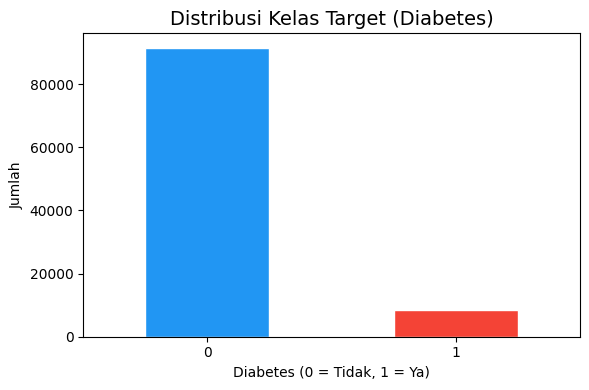

In [12]:
# 4.4 Distribusi Target (diabetes)
print('=== DISTRIBUSI TARGET ===')
print(df['diabetes'].value_counts())
print(f'\nPersentase:')
print(df['diabetes'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6, 4))
colors = ['#2196F3', '#F44336']
df['diabetes'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Distribusi Kelas Target (Diabetes)', fontsize=14)
plt.xlabel('Diabetes (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=100)
plt.show()


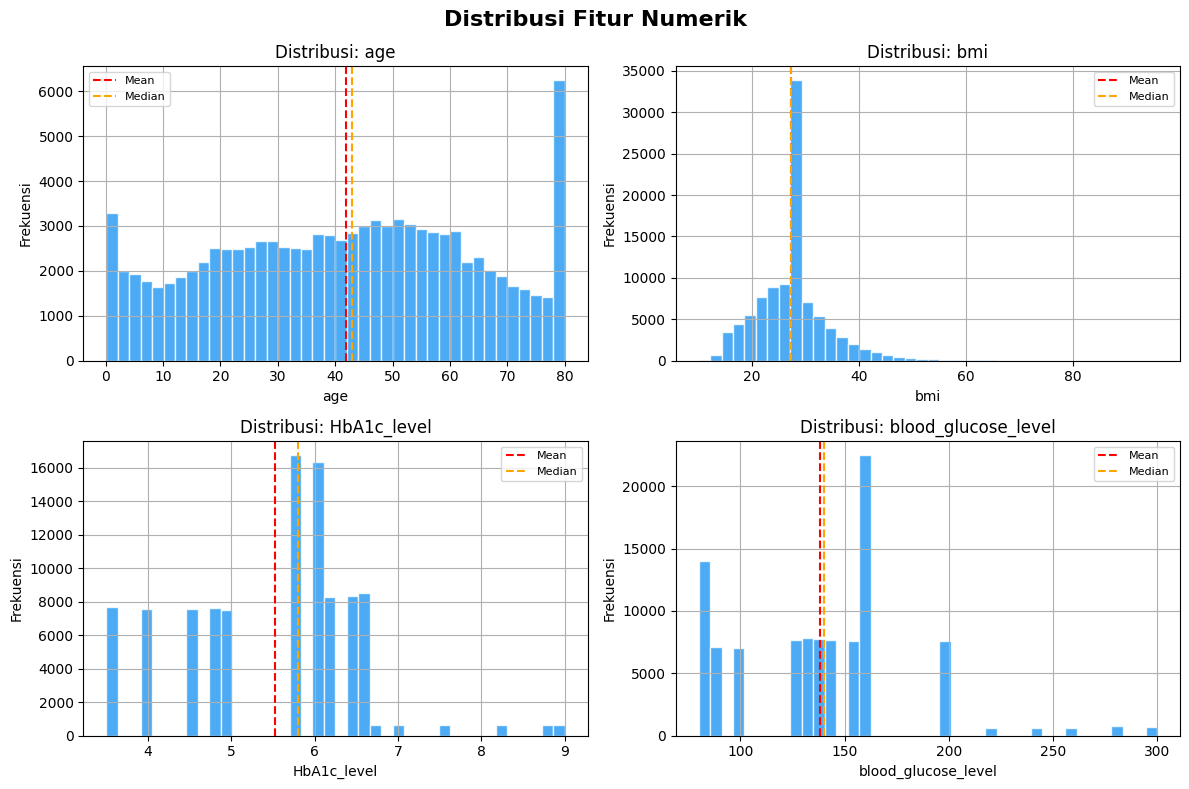

In [13]:
# 4.5 Distribusi Fitur Numerik
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    df[col].hist(ax=ax, bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribusi: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_fitur_numerik.png', dpi=100)
plt.show()

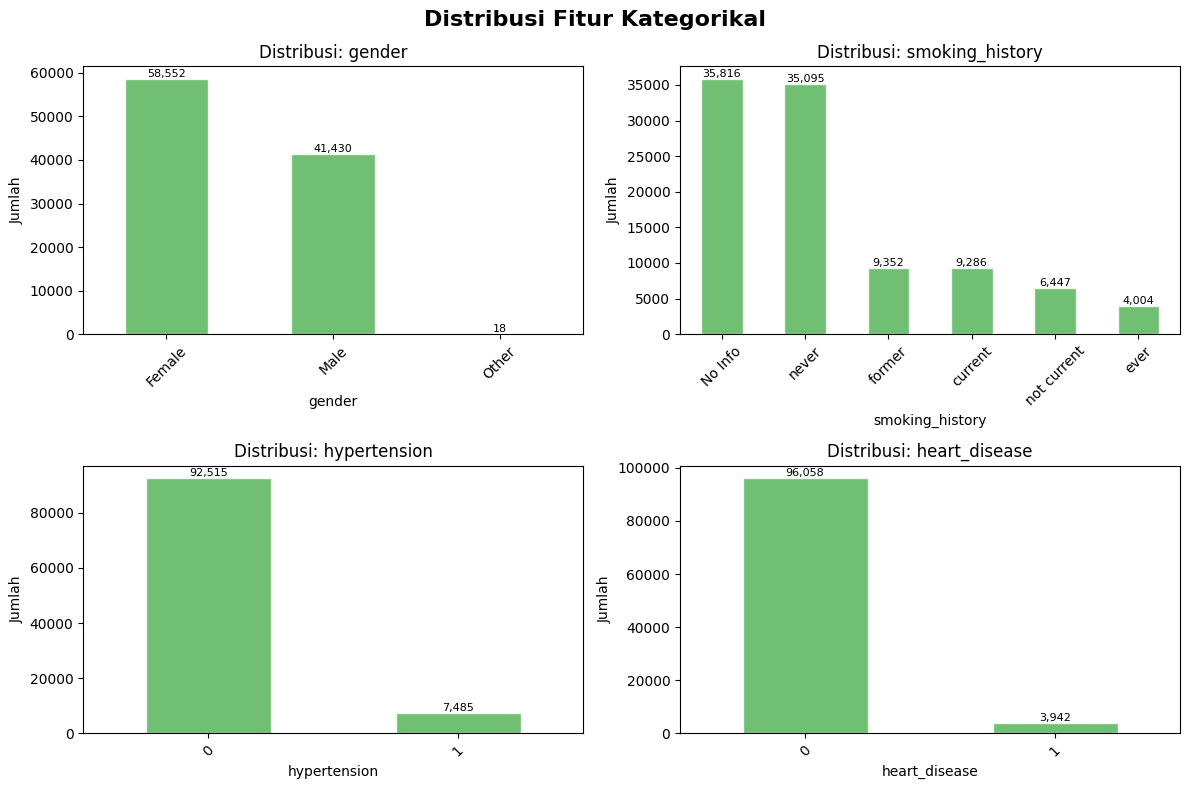

In [14]:
# 4.6 Distribusi Fitur Kategorikal
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_cols):
    ax = axes[i//2, i%2]
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='#4CAF50', edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribusi: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=45)
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2., bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_fitur_kategorikal.png', dpi=100)
plt.show()


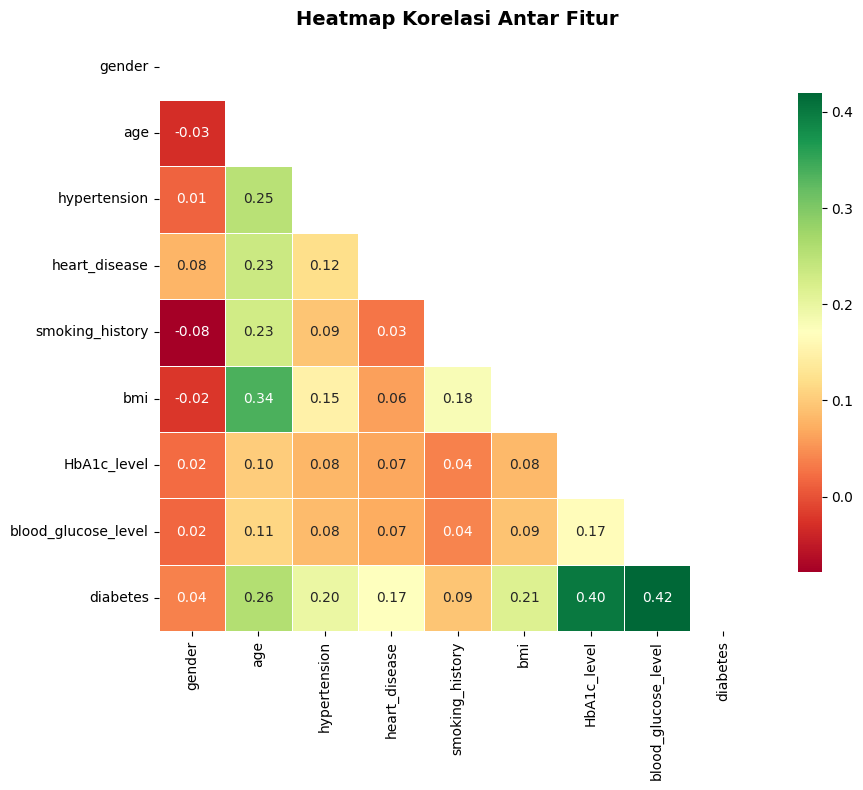


Korelasi fitur terhadap target (diabetes):
diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
smoking_history        0.094290
gender                 0.037411
Name: diabetes, dtype: float64


In [15]:
# 4.7 Heatmap Korelasi
df_corr = df.copy()
le_tmp = LabelEncoder()
df_corr['gender']          = le_tmp.fit_transform(df_corr['gender'])
df_corr['smoking_history'] = le_tmp.fit_transform(df_corr['smoking_history'])

corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=100)
plt.show()

# Tampilkan korelasi terhadap target
print('\nKorelasi fitur terhadap target (diabetes):')
print(corr_matrix['diabetes'].sort_values(ascending=False))


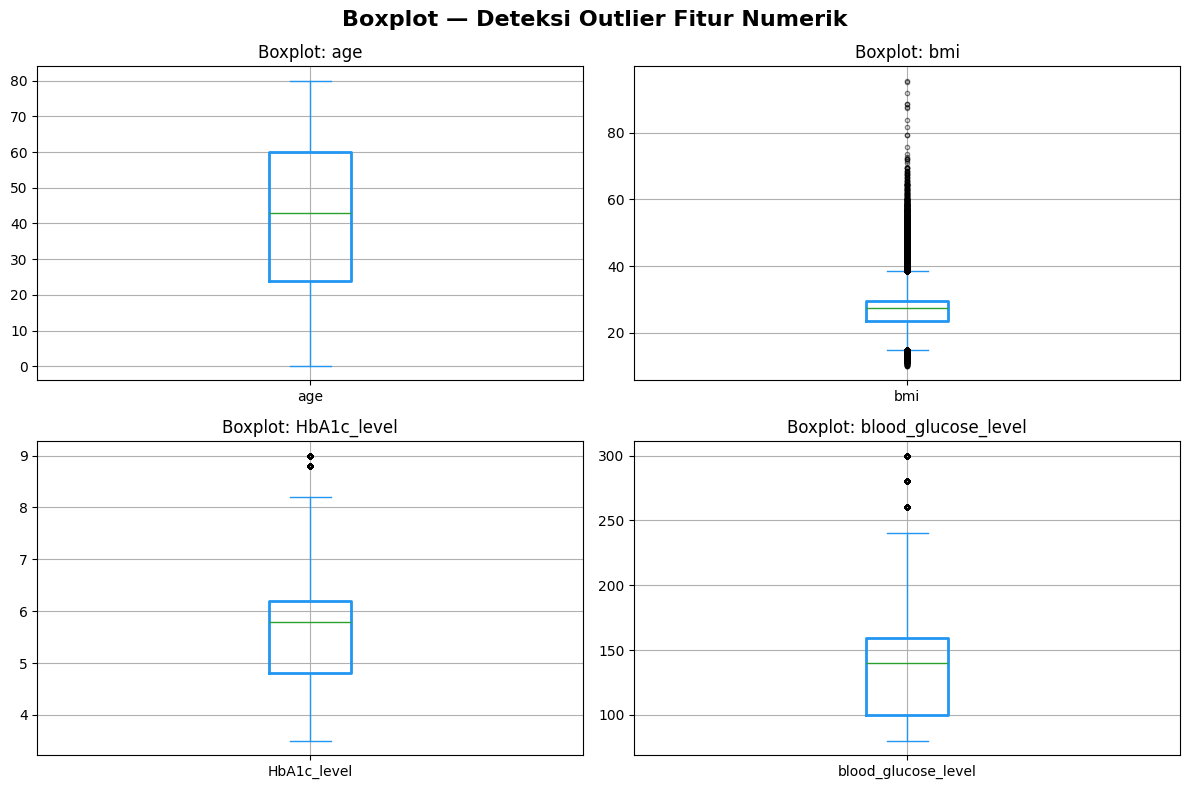

=== JUMLAH OUTLIER (Metode IQR) ===
  age                      :     0 outlier (0.00%)
  bmi                      :  7086 outlier (7.09%)
  HbA1c_level              :  1315 outlier (1.31%)
  blood_glucose_level      :  2038 outlier (2.04%)


In [16]:
# 4.8 Deteksi Outlier dengan Boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplot — Deteksi Outlier Fitur Numerik', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    df.boxplot(column=col, ax=ax, vert=True,
               boxprops=dict(color='#2196F3', linewidth=2),
               whiskerprops=dict(color='#2196F3'),
               capprops=dict(color='#2196F3'),
               flierprops=dict(marker='o', color='red', markersize=3, alpha=0.5))
    ax.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=100)
plt.show()

# Hitung jumlah outlier dengan metode IQR
print('=== JUMLAH OUTLIER (Metode IQR) ===')
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:25s}: {outlier_count:5d} outlier ({outlier_count/len(df)*100:.2f}%)')


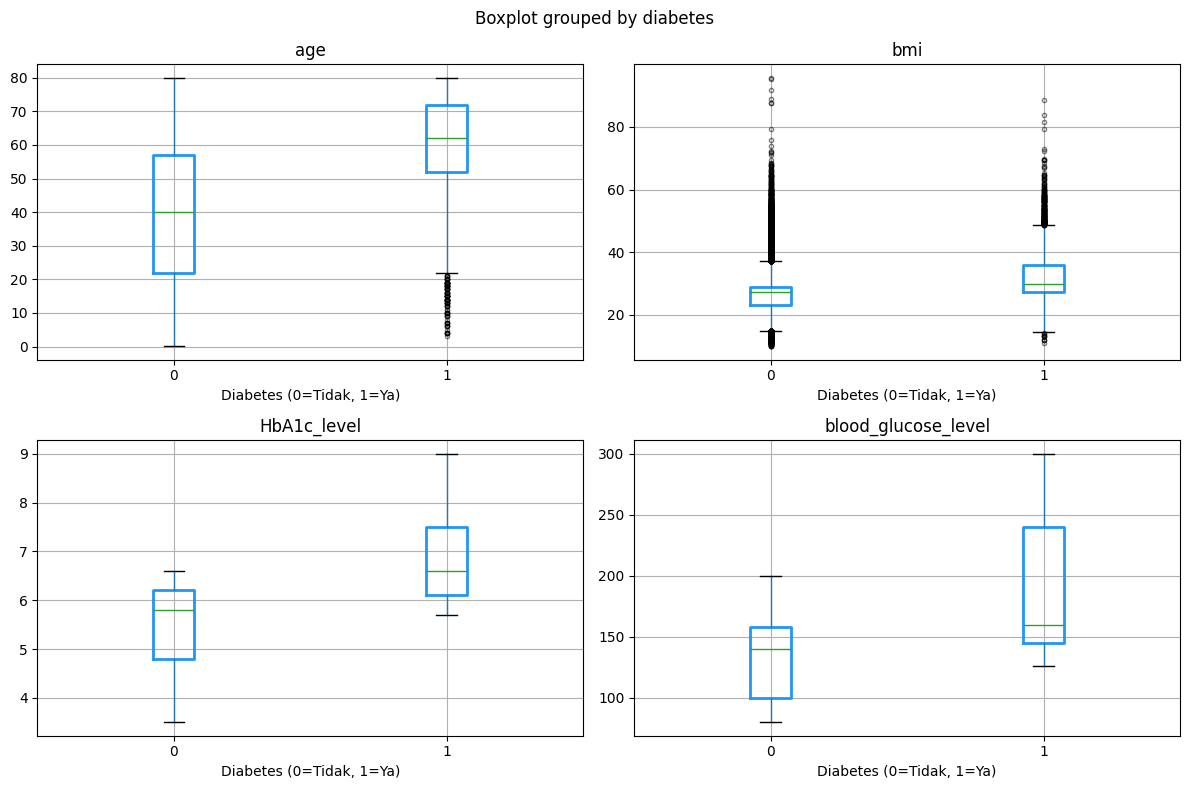

In [17]:
# 4.9 Hubungan Fitur Numerik dengan Target
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur Numerik per Kelas Diabetes', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    df.boxplot(column=col, by='diabetes', ax=ax,
               boxprops=dict(color='#2196F3', linewidth=2),
               flierprops=dict(marker='o', color='red', markersize=3, alpha=0.5))
    ax.set_title(f'{col}')
    ax.set_xlabel('Diabetes (0=Tidak, 1=Ya)')
    plt.sca(ax)
    plt.title(f'{col}')

plt.tight_layout()
plt.savefig('fitur_vs_target.png', dpi=100)
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# 5.1 Menyalin DataFrame agar data asli tidak berubah
df_processed = df.copy()
print('DataFrame berhasil disalin.')
print(f'Shape awal: {df_processed.shape}')


DataFrame berhasil disalin.
Shape awal: (100000, 9)


In [19]:
# 5.2 Menangani Missing Values
num_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
cat_features = ['gender', 'smoking_history']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_processed[num_features] = num_imputer.fit_transform(df_processed[num_features])
df_processed[cat_features] = cat_imputer.fit_transform(df_processed[cat_features])

print('=== MISSING VALUES SETELAH PENANGANAN ===')
print(df_processed.isnull().sum())

=== MISSING VALUES SETELAH PENANGANAN ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [20]:
# 5.3 Menghapus Data Duplikat
before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
after  = len(df_processed)

print('=== PENGHAPUSAN DUPLIKAT ===')
print(f'Baris sebelum : {before:,}')
print(f'Baris sesudah : {after:,}')
print(f'Duplikat dihapus: {before - after}')


=== PENGHAPUSAN DUPLIKAT ===
Baris sebelum : 100,000
Baris sesudah : 96,146
Duplikat dihapus: 3854


In [21]:
# 5.4 Encoding Data Kategorikal
le_gender  = LabelEncoder()
le_smoking = LabelEncoder()

df_processed['gender']          = le_gender.fit_transform(df_processed['gender'])
df_processed['smoking_history'] = le_smoking.fit_transform(df_processed['smoking_history'])

print('=== HASIL ENCODING ===')
print('Mapping gender  :', dict(zip(le_gender.classes_,  le_gender.transform(le_gender.classes_))))
print('Mapping smoking :', dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_))))


=== HASIL ENCODING ===
Mapping gender  : {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Mapping smoking : {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


In [22]:
# 5.5 Penanganan Outlier dengan IQR Clipping
print('=== PENANGANAN OUTLIER ===')
for col in num_features:
    Q1     = df_processed[col].quantile(0.25)
    Q3     = df_processed[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    before = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)
    print(f'  {col:25s}: {before} outlier di-clip ke [{lower:.3f}, {upper:.3f}]')


=== PENANGANAN OUTLIER ===
  age                      : 0 outlier di-clip ke [-28.500, 111.500]
  bmi                      : 5354 outlier di-clip ke [13.710, 39.550]
  HbA1c_level              : 1312 outlier di-clip ke [2.700, 8.300]
  blood_glucose_level      : 2031 outlier di-clip ke [11.500, 247.500]


In [23]:
# 5.6 Standarisasi Fitur Numerik (StandardScaler)
scaler = StandardScaler()
df_processed[num_features] = scaler.fit_transform(df_processed[num_features])

print('=== HASIL STANDARISASI ===')
print(df_processed[num_features].describe().round(3))


=== HASIL STANDARISASI ===
             age        bmi  HbA1c_level  blood_glucose_level
count  96146.000  96146.000    96146.000            96146.000
mean       0.000      0.000       -0.000               -0.000
std        1.000      1.000        1.000                1.000
min       -1.857     -2.250       -1.929               -1.489
25%       -0.792     -0.613       -0.690               -0.971
50%        0.054      0.049        0.263                0.064
75%        0.766      0.478        0.644                0.556
max        1.701      2.115        2.645                2.846


In [24]:
# 5.7 Verifikasi Hasil Preprocessing
print('=== RINGKASAN HASIL PREPROCESSING ===')
print(f'Shape            : {df_processed.shape}')
print(f'Missing values   : {df_processed.isnull().sum().sum()}')
print(f'Duplikat         : {df_processed.duplicated().sum()}')
print(f'Tipe data:')
print(df_processed.dtypes)
print('\n5 baris pertama setelah preprocessing:')
df_processed.head()


=== RINGKASAN HASIL PREPROCESSING ===
Shape            : (96146, 9)
Missing values   : 0
Duplikat         : 130
Tipe data:
gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level    float64
diabetes                 int64
dtype: object

5 baris pertama setelah preprocessing:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.310970,1.024846,0.064090,0
1,0,0.543372,0,0,0,0.048828,1.024846,-1.488726,0
2,1,-0.614096,0,0,4,0.048828,0.167291,0.529935,0
3,0,-0.257952,0,0,1,-0.604890,-0.499697,0.452295,0
4,1,1.522768,1,1,1,-1.164014,-0.690265,0.452295,0


In [26]:
# 5.8 Split Data Train/Test dan Simpan
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== HASIL SPLIT DATA ===')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test :\n{y_test.value_counts()}')

# Simpan ke folder diabetes_preprocessing
os.makedirs('diabetes_preprocessing', exist_ok=True)
X_train.to_csv('diabetes_preprocessing/X_train.csv', index=False)
X_test.to_csv( 'diabetes_preprocessing/X_test.csv',  index=False)
y_train.to_csv('diabetes_preprocessing/y_train.csv', index=False)
y_test.to_csv( 'diabetes_preprocessing/y_test.csv',  index=False)

print('\n✅  Dataset berhasil disimpan ke folder diabetes_preprocessing/')

=== HASIL SPLIT DATA ===
X_train : (76916, 8)  |  X_test : (19230, 8)
y_train : (76916,)  |  y_test : (19230,)

Distribusi y_train:
diabetes
0    70130
1     6786
Name: count, dtype: int64

Distribusi y_test :
diabetes
0    17534
1     1696
Name: count, dtype: int64

✅  Dataset berhasil disimpan ke folder diabetes_preprocessing/
